# Stage 0: Setup and Data Loading

In this stage, we download the Air Quality dataset from Kaggle and load it into a Pandas DataFrame.

In [38]:
import os
import pandas as pd

csv_path = os.path.join("dataset", "city_day.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df = df[['PM2.5', 'NO2', 'AQI']].dropna()
    print(f"Dataset loaded. Rows: {len(df)}")
    display(df.head())
else:
    raise FileNotFoundError(f"File tidak ditemukan: {csv_path}\nCurrent dir: {os.getcwd()}")

Dataset loaded. Rows: 23849


,PM2.5,NO2,AQI
28,83.13,28.71,209.0
29,79.84,28.68,328.0
30,94.52,32.66,514.0
31,135.99,42.08,782.0
32,178.33,35.31,914.0


In [39]:
# Load the city_day.csv file from the local dataset folder
csv_path = os.path.join("dataset", "city_day.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    
    # Filter only necessary columns and remove missing values
    df = df[['PM2.5', 'NO2', 'AQI']].dropna()
    
    print(f"Dataset loaded and cleaned successfully. Remaining rows: {len(df)}")
    print("First 5 rows of cleaned data:")
    display(df.head())
else:
    print(f"File not found: {csv_path}. Did the download or file copying stage fail?")

Dataset loaded and cleaned successfully. Remaining rows: 23849
First 5 rows of cleaned data:


,PM2.5,NO2,AQI
28,83.13,28.71,209.0
29,79.84,28.68,328.0
30,94.52,32.66,514.0
31,135.99,42.08,782.0
32,178.33,35.31,914.0


# Stage 1: Manual Fuzzy Inference System (Sugeno) for Air Quality

Study Case: Predicting Air Quality Index (AQI) based on PM2.5 and NO2 levels.

We use fuzzy logic to map environmental sensor data into human-readable air quality categories.

In [40]:
from helper import fuzzify, evaluate_rule, sugeno_defuzzification
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Membership Function (MF) Definitions

We define two inputs based on Indian Air Quality standards:
- **PM2.5**: Particulate Matter 2.5 (Low, Medium, High).
- **NO2**: Nitrogen Dioxide (Low, Medium, High).

And one output:
- **AQI**: Air Quality Index (Zero-order Sugeno constants).

In [41]:
# PM2.5 (0-500 range)
pm25_mf = {
    'Low': ('left_shoulder', [30, 60]),
    'Medium': ('triangular', [45, 90, 135]),
    'High': ('right_shoulder', [110, 200])
}

# NO2 (0-400 range)
no2_mf = {
    'Low': ('left_shoulder', [40, 80]),
    'Medium': ('triangular', [60, 130, 200]),
    'High': ('right_shoulder', [160, 300])
}

## 2. Rule Base Definitions

Rules determine the resulting AQI constant based on input states:

In [42]:
rule_base = [
    {'if': [('pm2.5', 'High'), ('no2', 'High')], 'then': 500},   # Severe
    {'if': [('pm2.5', 'High'), ('no2', 'Medium')], 'then': 350}, # Very Poor
    {'if': [('pm2.5', 'High'), ('no2', 'Low')], 'then': 250},    # Poor
    {'if': [('pm2.5', 'Medium'), ('no2', 'High')], 'then': 350}, # Very Poor
    {'if': [('pm2.5', 'Medium'), ('no2', 'Medium')], 'then': 150}, # Moderate
    {'if': [('pm2.5', 'Medium'), ('no2', 'Low')], 'then': 100},    # Satisfactory
    {'if': [('pm2.5', 'Low'), ('no2', 'High')], 'then': 250},    # Poor
    {'if': [('pm2.5', 'Low'), ('no2', 'Medium')], 'then': 100},    # Satisfactory
    {'if': [('pm2.5', 'Low'), ('no2', 'Low')], 'then': 50}       # Good
]

## 3. Inference Function

In [43]:
def predict_aqi(pm25_val, no2_val):
    # Fuzzification
    p_fuzzy = fuzzify(pm25_val, pm25_mf)
    n_fuzzy = fuzzify(no2_val, no2_mf)
    
    memberships = {'pm2.5': p_fuzzy, 'no2': n_fuzzy}
    
    # Rule Evaluation
    firing_strengths = []
    rule_outputs = []
    
    for rule in rule_base:
        w, z = evaluate_rule(memberships, rule)
        firing_strengths.append(w)
        rule_outputs.append(z)
        
    # Defuzzification (Sugeno)
    return sugeno_defuzzification(firing_strengths, rule_outputs)

# Test Case 1: High Pollution (PM2.5: 220, NO2: 320)
print(f"Predicted AQI (High Pollution): {predict_aqi(220, 320):.2f}")

# Test Case 2: Clean Air (PM2.5: 15, NO2: 20)
print(f"Predicted AQI (Clean Air): {predict_aqi(15, 20):.2f}")

# Test Case 3: Moderate Conditions (PM2.5: 90, NO2: 130)
print(f"Predicted AQI (Moderate): {predict_aqi(90, 130):.2f}")

Predicted AQI (High Pollution): 500.00
Predicted AQI (Clean Air): 50.00
Predicted AQI (Moderate): 150.00


# Stage 2: Validation with Real-World Data (Delhi)

In this stage, we take real pollutant measurements from the city of **Delhi** and run them through our manual fuzzy logic system to see how well it approximates the official AQI.

In [44]:
# 1. Filter and Clean Data for Delhi
# Since the global 'df' is now filtered to 3 columns in Stage 0, we reload to filter by City
csv_path = os.path.join("dataset", "city_day.csv")

if os.path.exists(csv_path):
    # Load raw data to allow filtering by City
    raw_df = pd.read_csv(csv_path)
    delhi_df = raw_df[raw_df['City'] == 'Delhi'].copy()
    
    # Select columns and drop NaNs
    delhi_df = delhi_df[['Date', 'PM2.5', 'NO2', 'AQI']].dropna()
    delhi_df['Date'] = pd.to_datetime(delhi_df['Date'])
    
    print(f'Cleaned data points for Delhi: {len(delhi_df)}')
    display(delhi_df.head())
else:
    print(f'File not found: {csv_path}.')

Cleaned data points for Delhi: 1998


,Date,PM2.5,NO2,AQI
10229,2015-01-01,313.22,36.39,472.0
10230,2015-01-02,186.18,32.87,454.0
10231,2015-01-03,87.18,30.31,143.0
10232,2015-01-04,151.84,36.91,319.0
10233,2015-01-05,146.60,34.92,325.0


In [45]:
# 2. Apply Fuzzy Inference to the dataset
print('Calculating predicted AQI for all rows...')
delhi_df['Predicted_AQI'] = delhi_df.apply(
    lambda row: predict_aqi(row['PM2.5'], row['NO2']), axis=1
)

print('Inference complete.')
display(delhi_df[['Date', 'AQI', 'Predicted_AQI']].head())

Calculating predicted AQI for all rows...
Inference complete.


,Date,AQI,Predicted_AQI
10229,2015-01-01,472.0,250.0
10230,2015-01-02,454.0,250.0
10231,2015-01-03,143.0,100.0
10232,2015-01-04,319.0,250.0
10233,2015-01-05,325.0,250.0


## Visualization: Actual vs Predicted AQI

We plot the official AQI against our fuzzy logic predictions to visualize the accuracy of our manual rules.

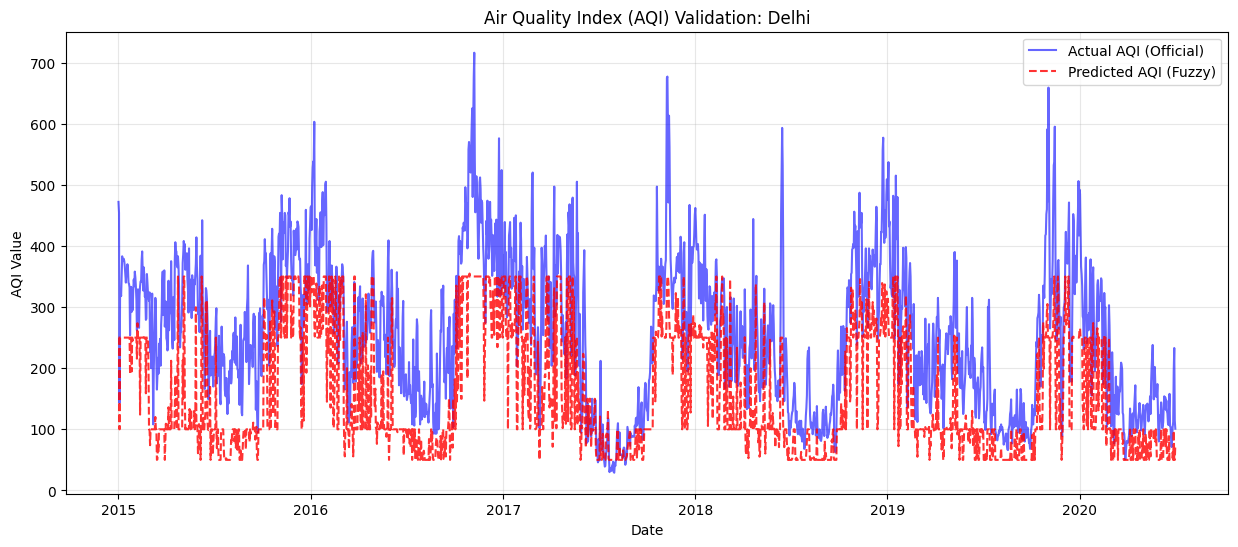

Mean Absolute Error of Manual Fuzzy System: 103.33


In [46]:
# 3. Visualization
plt.figure(figsize=(15, 6))
plt.plot(delhi_df['Date'], delhi_df['AQI'], label='Actual AQI (Official)', color='blue', alpha=0.6)
plt.plot(delhi_df['Date'], delhi_df['Predicted_AQI'], label='Predicted AQI (Fuzzy)', color='red', linestyle='--', alpha=0.8)

plt.title('Air Quality Index (AQI) Validation: Delhi')
plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Simple Accuracy Metric: Mean Absolute Error
mae = (delhi_df['AQI'] - delhi_df['Predicted_AQI']).abs().mean()
print(f'Mean Absolute Error of Manual Fuzzy System: {mae:.2f}')

# Stage 4: ANN-Based Tuning of Fuzzy Membership Function Parameters

## Konsep & Pendekatan

Pada Stage 1, parameter Membership Function (MF) — seperti titik-titik pada fungsi trapesium/segitiga — ditentukan **secara manual berdasarkan intuisi**. Hasilnya tentu suboptimal.

Di Stage 3 ini, kita menggunakan **Artificial Neural Network (ANN)** untuk secara otomatis mempelajari parameter MF yang optimal langsung dari data.

### Arsitektur: ANFIS-Inspired (Adaptive Neuro-Fuzzy)

Pendekatan yang digunakan adalah **ANFIS (Adaptive Neuro-Fuzzy Inference System)**, di mana:
- **Layer 1 (Fuzzification):** Node dengan fungsi sigmoid yang bisa dipelajari, merepresentasikan MF.
- **Layer 2 (Rule Firing):** Mengalikan output Layer 1 (AND operation).
- **Layer 3 (Normalization):** Menormalisasi firing strength tiap rule.
- **Layer 4 (Consequent):** Parameter output Sugeno per rule (bisa dipelajari).
- **Layer 5 (Defuzzification):** Weighted average — output akhir AQI.

Seluruh jaringan ini **end-to-end differentiable** sehingga bisa dilatih dengan backpropagation (Adam optimizer).

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.11.0+cpu


## 1. Persiapan Data

Kita menggunakan data Delhi yang sama seperti Stage 2, lalu membaginya menjadi train/test set.

In [48]:
# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

# Load & clean Delhi data
csv_path = os.path.join('dataset', 'city_day.csv')
raw_df = pd.read_csv(csv_path)
delhi_df = raw_df[raw_df['City'] == 'Delhi'][['PM2.5', 'NO2', 'AQI']].dropna().copy()

# Subsample — tanpa groupby untuk hindari KeyError
N_SAMPLE = 300
delhi_df['AQI_bucket'] = pd.cut(delhi_df['AQI'], bins=5, labels=False)
sampled_parts = []
for bucket, group in delhi_df.groupby('AQI_bucket'):
    sampled_parts.append(group.sample(min(len(group), N_SAMPLE // 5), random_state=42))
delhi_df = pd.concat(sampled_parts).reset_index(drop=True)
delhi_df = delhi_df[['PM2.5', 'NO2', 'AQI']]  # buang AQI_bucket dengan select kolom

print(f'Subsample size: {len(delhi_df)} rows (dari total Delhi data)')
print(delhi_df.describe())

# Normalize inputs ke [0, 1]
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = scaler_X.fit_transform(delhi_df[['PM2.5', 'NO2']].values)
y = scaler_y.fit_transform(delhi_df[['AQI']].values)

# Train/Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert ke PyTorch Tensor
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

print(f'\nTrain size: {len(X_train)} | Test size: {len(X_test)}')

Using device: cpu
PyTorch version: 2.11.0+cpu
Subsample size: 254 rows (dari total Delhi data)
            PM2.5         NO2         AQI
count  254.000000  254.000000  254.000000
mean   164.512205   59.783780  316.098425
std    131.319101   29.287089  159.518130
min     10.880000   14.860000   30.000000
25%     58.047500   37.860000  177.500000
50%    119.235000   54.920000  314.000000
75%    247.015000   76.695000  452.000000
max    685.360000  162.500000  716.000000

Train size: 203 | Test size: 51


## 2. Definisi Model ANFIS

### Detail Arsitektur

| Layer | Nama | Fungsi | Parameter yang Dipelajari |
|---|---|---|---|
| 1 | Fuzzification | Gaussian MF: `exp(-(x-c)²/2σ²)` | `c` (center), `σ` (width) per variabel per term |
| 2 | Rule Firing | Produk (AND) dari membership tiap rule | - |
| 3 | Normalization | `w_i / Σw_i` | - |
| 4 | Consequent | Linear Sugeno: `p·x₁ + q·x₂ + r` | `p, q, r` per rule |
| 5 | Output | Weighted average | - |

Dengan 3 term per variabel dan 2 variabel input, terdapat **9 rules** (3×3), konsisten dengan Stage 1.

In [49]:
class ANFISLayer(nn.Module):
    def __init__(self, n_inputs=2, n_terms=3):
        super(ANFISLayer, self).__init__()
        self.n_inputs = n_inputs
        self.n_terms  = n_terms
        self.n_rules  = n_terms ** n_inputs

        init_centers = torch.linspace(0.1, 0.9, n_terms).unsqueeze(0).repeat(n_inputs, 1)
        self.centers = nn.Parameter(init_centers)
        self.sigmas  = nn.Parameter(torch.ones(n_inputs, n_terms) * 0.3)
        self.consequents = nn.Parameter(torch.randn(self.n_rules, n_inputs + 1) * 0.1)

        import itertools
        self.rule_idx = list(itertools.product(range(n_terms), repeat=n_inputs))

    def forward(self, x):
        batch = x.size(0)

        # Layer 1: Fuzzification
        x_exp = x.unsqueeze(2)
        c_exp = self.centers.unsqueeze(0)
        s_exp = self.sigmas.unsqueeze(0).abs() + 1e-6
        mu = torch.exp(-((x_exp - c_exp) ** 2) / (2 * s_exp ** 2))

        # Layer 2: Rule Firing — FIX: pakai stack bukan inplace multiply
        w_list = []
        for r, idx in enumerate(self.rule_idx):
            w_r = mu[:, 0, idx[0]]
            for i in range(1, len(idx)):
                w_r = w_r * mu[:, i, idx[i]]  # bukan inplace, buat tensor baru
            w_list.append(w_r)
        w = torch.stack(w_list, dim=1)  # (batch, n_rules)

        # Layer 3: Normalisasi
        w_sum  = w.sum(dim=1, keepdim=True) + 1e-8
        w_norm = w / w_sum

        # Layer 4: Consequent
        x_aug = torch.cat([x, torch.ones(batch, 1, device=x.device)], dim=1)
        f = x_aug @ self.consequents.T

        # Layer 5: Output
        output = (w_norm * f).sum(dim=1, keepdim=True)
        return output


model = ANFISLayer(n_inputs=2, n_terms=3).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model: ANFIS | Rules: {model.n_rules} | Total trainable parameters: {total_params}')
print(f'  Centers shape    : {model.centers.shape}')
print(f'  Sigmas shape     : {model.sigmas.shape}')
print(f'  Consequents shape: {model.consequents.shape}')

Model: ANFIS | Rules: 9 | Total trainable parameters: 39
  Centers shape    : torch.Size([2, 3])
  Sigmas shape     : torch.Size([2, 3])
  Consequents shape: torch.Size([9, 3])


## 3. Training Loop

Kita menggunakan:
- **Loss:** Mean Squared Error (MSE)
- **Optimizer:** Adam (learning rate = 0.01)
- **Scheduler:** ReduceLROnPlateau — turunkan lr bila validation loss stagnan
- **Early Stopping:** Stop bila tidak ada improvement selama 30 epoch

In [50]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

# ── Config yang dipercepat ─────────────────────────────────────────────────
N_EPOCHS = 150   # dikurangi dari 500
PATIENCE = 20    # early stopping lebih agresif

train_losses = []
val_losses   = []
best_val_loss   = float('inf')
best_state_dict = None
no_improve      = 0

print('Starting training...')
print(f'{"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>12} | {"LR":>10}')
print('-' * 50)

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = np.mean(batch_losses)

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_test_t), y_test_t).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss   = val_loss
        best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if epoch % 25 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{epoch:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | {lr_now:>10.6f}')

    if no_improve >= PATIENCE:
        print(f'\nEarly stopping di epoch {epoch}')
        break

model.load_state_dict(best_state_dict)
print(f'\nSelesai. Best val loss: {best_val_loss:.6f}')

Starting training...
 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------
     1 |     0.174772 |     0.101283 |   0.010000
    25 |     0.007020 |     0.013689 |   0.005000
    50 |     0.006201 |     0.012831 |   0.005000
    75 |     0.005762 |     0.010944 |   0.005000
   100 |     0.005441 |     0.010694 |   0.005000
   125 |     0.005291 |     0.010335 |   0.005000
   150 |     0.005214 |     0.010070 |   0.005000

Selesai. Best val loss: 0.010046


## 4. Visualisasi Membership Function: Sebelum vs Sesudah Tuning

Kita bandingkan MF manual (Stage 1) dengan MF Gaussian yang sudah di-tune ANN.

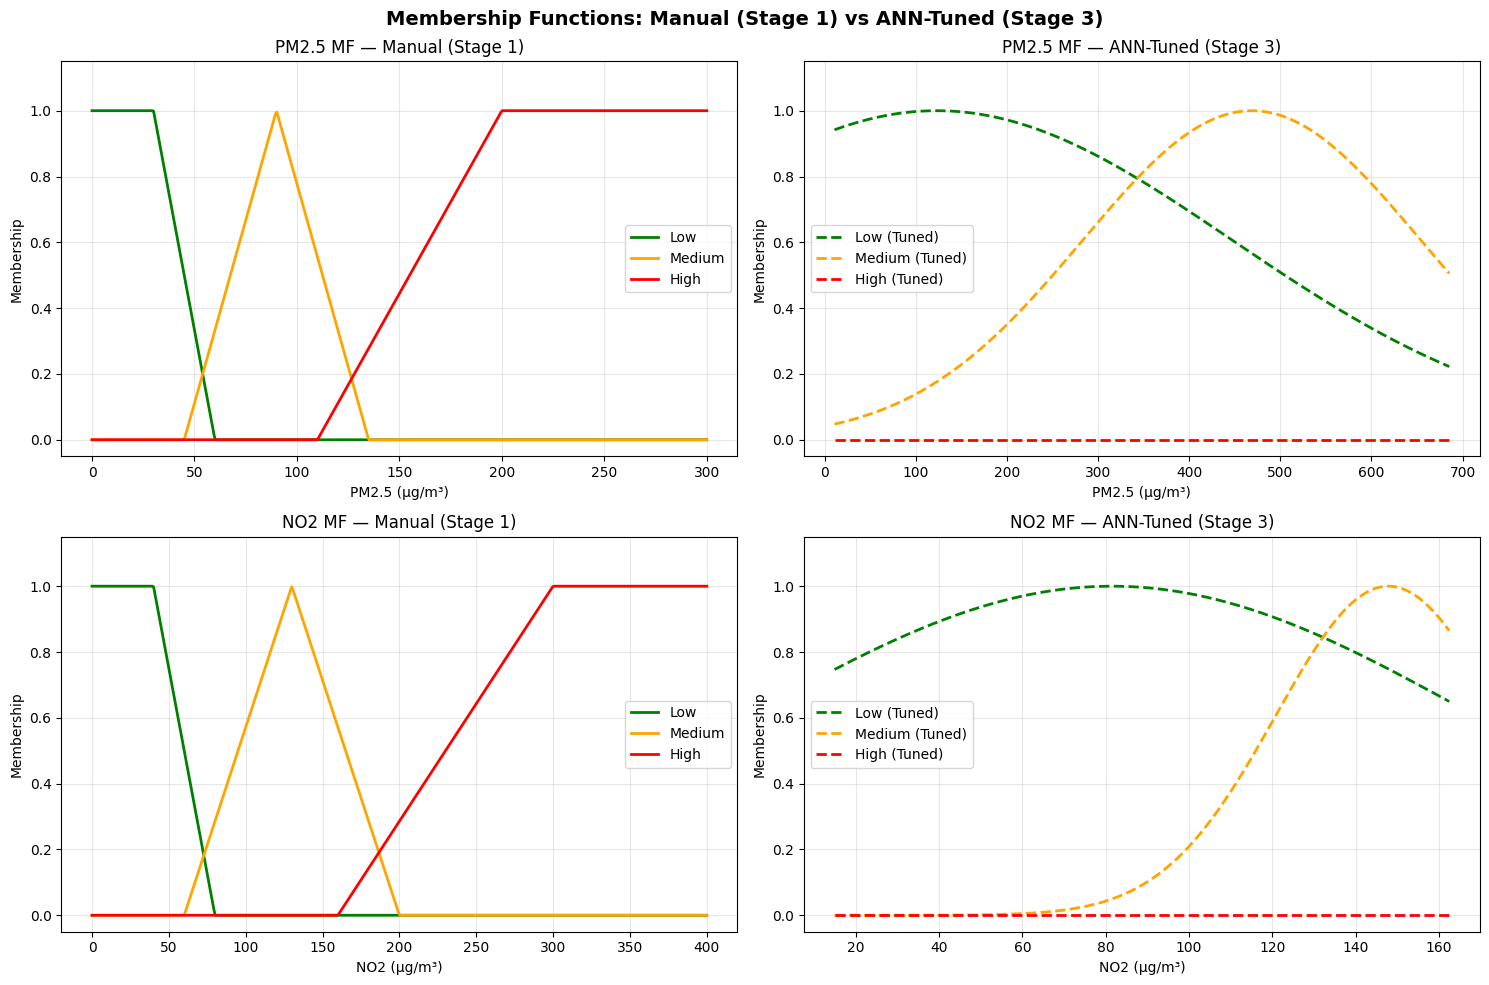

In [51]:
from helper import fuzzify  # untuk MF manual Stage 1

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Membership Functions: Manual (Stage 1) vs ANN-Tuned (Stage 3)', fontsize=14, fontweight='bold')

# ── Helper untuk MF manual ────────────────────────────────────────────────
def left_shoulder(x, params):
    a, b = params
    if x <= a: return 1.0
    elif x >= b: return 0.0
    else: return (b - x) / (b - a)

def right_shoulder(x, params):
    a, b = params
    if x <= a: return 0.0
    elif x >= b: return 1.0
    else: return (x - a) / (b - a)

def triangular(x, params):
    a, b, c = params
    if x <= a or x >= c: return 0.0
    elif x <= b: return (x - a) / (b - a)
    else: return (c - x) / (c - b)

# MF Manual Stage 1
pm25_manual = {'Low': ('left_shoulder', [30, 60]), 'Medium': ('triangular', [45, 90, 135]), 'High': ('right_shoulder', [110, 200])}
no2_manual  = {'Low': ('left_shoulder', [40, 80]), 'Medium': ('triangular', [60, 130, 200]), 'High': ('right_shoulder', [160, 300])}

pm25_range_raw = np.linspace(0, 300, 500)
no2_range_raw  = np.linspace(0, 400, 500)

# ── Plot PM2.5 Manual ─────────────────────────────────────────────────────
ax = axes[0, 0]
colors = ['green', 'orange', 'red']
for color, (label, (mf_type, params)) in zip(colors, pm25_manual.items()):
    fn = {'left_shoulder': left_shoulder, 'triangular': triangular, 'right_shoulder': right_shoulder}[mf_type]
    vals = [fn(x, params) for x in pm25_range_raw]
    ax.plot(pm25_range_raw, vals, color=color, label=label, linewidth=2)
ax.set_title('PM2.5 MF — Manual (Stage 1)'); ax.set_xlabel('PM2.5 (μg/m³)'); ax.set_ylabel('Membership')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.15)

# ── Plot NO2 Manual ───────────────────────────────────────────────────────
ax = axes[1, 0]
for color, (label, (mf_type, params)) in zip(colors, no2_manual.items()):
    fn = {'left_shoulder': left_shoulder, 'triangular': triangular, 'right_shoulder': right_shoulder}[mf_type]
    vals = [fn(x, params) for x in no2_range_raw]
    ax.plot(no2_range_raw, vals, color=color, label=label, linewidth=2)
ax.set_title('NO2 MF — Manual (Stage 1)'); ax.set_xlabel('NO2 (μg/m³)'); ax.set_ylabel('Membership')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.15)

# ── Plot PM2.5 ANN-Tuned ──────────────────────────────────────────────────
model.eval()
centers = model.centers.detach().cpu().numpy()  # (2, 3)
sigmas  = model.sigmas.detach().cpu().abs().numpy()  # (2, 3)

# PM2.5: input 0 — range [0,1] normalized, tampilkan dalam skala asli
pm25_min, pm25_max = scaler_X.data_min_[0], scaler_X.data_max_[0]
no2_min,  no2_max  = scaler_X.data_min_[1], scaler_X.data_max_[1]

x_norm = np.linspace(0, 1, 500)

ax = axes[0, 1]
labels = ['Low (Tuned)', 'Medium (Tuned)', 'High (Tuned)']
for k, (color, label) in enumerate(zip(colors, labels)):
    mf_vals = np.exp(-((x_norm - centers[0, k])**2) / (2 * sigmas[0, k]**2))
    x_real = x_norm * (pm25_max - pm25_min) + pm25_min
    ax.plot(x_real, mf_vals, color=color, label=label, linewidth=2, linestyle='--')
ax.set_title('PM2.5 MF — ANN-Tuned (Stage 3)'); ax.set_xlabel('PM2.5 (μg/m³)'); ax.set_ylabel('Membership')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.15)

# ── Plot NO2 ANN-Tuned ────────────────────────────────────────────────────
ax = axes[1, 1]
for k, (color, label) in enumerate(zip(colors, labels)):
    mf_vals = np.exp(-((x_norm - centers[1, k])**2) / (2 * sigmas[1, k]**2))
    x_real = x_norm * (no2_max - no2_min) + no2_min
    ax.plot(x_real, mf_vals, color=color, label=label, linewidth=2, linestyle='--')
ax.set_title('NO2 MF — ANN-Tuned (Stage 3)'); ax.set_xlabel('NO2 (μg/m³)'); ax.set_ylabel('Membership')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(-0.05, 1.15)

plt.tight_layout()
plt.savefig('stage3_mf_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Training Loss Curve

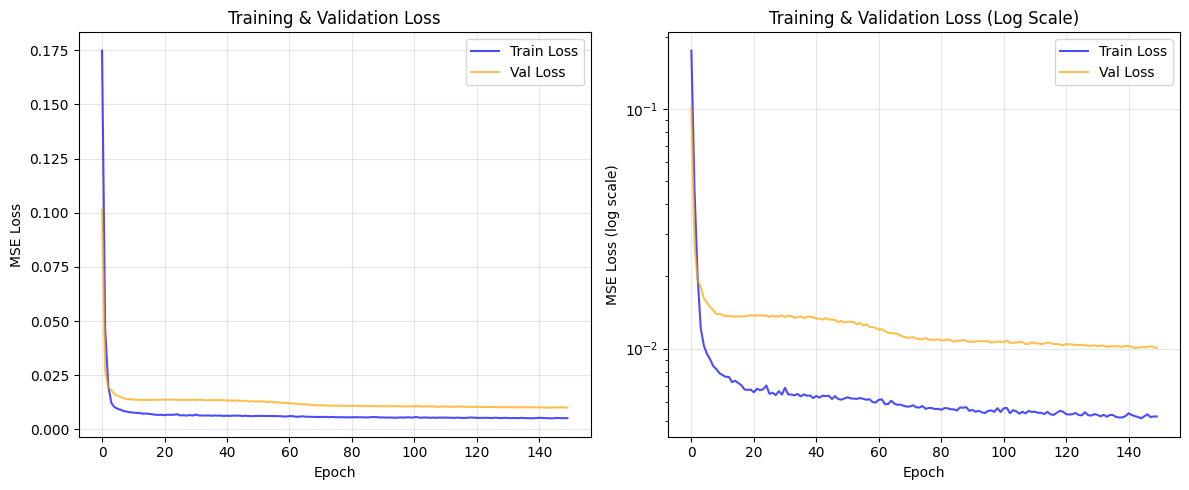

In [52]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', alpha=0.7)
plt.plot(val_losses,   label='Val Loss',   color='orange', alpha=0.7)
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', color='blue', alpha=0.7)
plt.plot(val_losses,   label='Val Loss',   color='orange', alpha=0.7)
plt.yscale('log')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss (log scale)')
plt.title('Training & Validation Loss (Log Scale)')
plt.legend(); plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('stage3_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Evaluasi & Perbandingan: Manual FIS vs ANN-Tuned ANFIS

In [53]:
# ── Prediksi ANN-Tuned ────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_pred_norm = model(X_test_t).cpu().numpy()

# Inverse transform ke skala AQI asli
y_pred_ann  = scaler_y.inverse_transform(y_pred_norm).flatten()
y_true      = scaler_y.inverse_transform(y_test).flatten()

# ── Prediksi Manual FIS (Stage 1) ────────────────────────────────────────
X_test_raw = scaler_X.inverse_transform(X_test)
y_pred_manual = np.array([predict_aqi(row[0], row[1]) for row in X_test_raw])

# ── Metrics ───────────────────────────────────────────────────────────────
mae_manual = mean_absolute_error(y_true, y_pred_manual)
mae_ann    = mean_absolute_error(y_true, y_pred_ann)
r2_manual  = r2_score(y_true, y_pred_manual)
r2_ann     = r2_score(y_true, y_pred_ann)

rmse_manual = np.sqrt(np.mean((y_true - y_pred_manual)**2))
rmse_ann    = np.sqrt(np.mean((y_true - y_pred_ann)**2))

print('=' * 60)
print(f'{'Metric':<20} | {'Manual FIS (Stage 1)':>18} | {'ANN-Tuned (Stage 3)':>18}')
print('-' * 60)
print(f'{'MAE':<20} | {mae_manual:>18.2f} | {mae_ann:>18.2f}')
print(f'{'RMSE':<20} | {rmse_manual:>18.2f} | {rmse_ann:>18.2f}')
print(f'{'R² Score':<20} | {r2_manual:>18.4f} | {r2_ann:>18.4f}')
print('=' * 60)

improvement_mae  = (mae_manual  - mae_ann)  / mae_manual  * 100
improvement_rmse = (rmse_manual - rmse_ann) / rmse_manual * 100
print(f'\n📈 Improvement MAE  : {improvement_mae:.1f}%')
print(f'📈 Improvement RMSE : {improvement_rmse:.1f}%')
print(f'📈 R² Improvement   : {r2_ann - r2_manual:+.4f}')

Metric               | Manual FIS (Stage 1) | ANN-Tuned (Stage 3)
------------------------------------------------------------
MAE                  |             139.18 |              52.85
RMSE                 |             163.06 |              68.76
R² Score             |             0.0799 |             0.8364

📈 Improvement MAE  : 62.0%
📈 Improvement RMSE : 57.8%
📈 R² Improvement   : +0.7565


## 7. Visualisasi: Actual vs Predicted AQI (Manual vs ANN-Tuned)

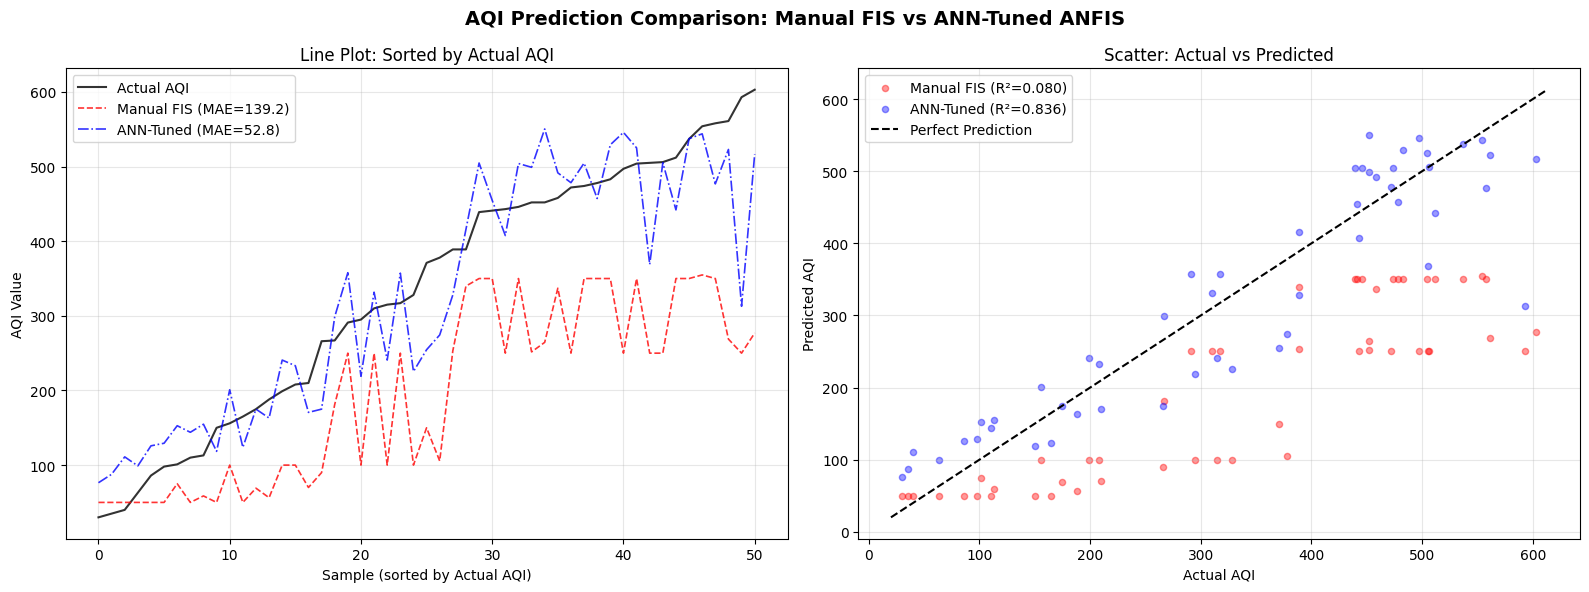

In [54]:
# Sort by actual AQI untuk scatter plot yang lebih rapi
sort_idx = np.argsort(y_true)
y_true_s   = y_true[sort_idx]
y_manual_s = y_pred_manual[sort_idx]
y_ann_s    = y_pred_ann[sort_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('AQI Prediction Comparison: Manual FIS vs ANN-Tuned ANFIS', fontsize=14, fontweight='bold')

# ── Plot 1: Line comparison ───────────────────────────────────────────────
ax = axes[0]
ax.plot(y_true_s,   label='Actual AQI',         color='black',  linewidth=1.5, alpha=0.8)
ax.plot(y_manual_s, label=f'Manual FIS (MAE={mae_manual:.1f})',  color='red',    linewidth=1.2, linestyle='--', alpha=0.8)
ax.plot(y_ann_s,    label=f'ANN-Tuned (MAE={mae_ann:.1f})',     color='blue',   linewidth=1.2, linestyle='-.',  alpha=0.8)
ax.set_xlabel('Sample (sorted by Actual AQI)')
ax.set_ylabel('AQI Value')
ax.set_title('Line Plot: Sorted by Actual AQI')
ax.legend(); ax.grid(alpha=0.3)

# ── Plot 2: Scatter — Actual vs Predicted ─────────────────────────────────
ax = axes[1]
ax.scatter(y_true, y_pred_manual, alpha=0.4, color='red',  s=20, label=f'Manual FIS (R²={r2_manual:.3f})')
ax.scatter(y_true, y_pred_ann,    alpha=0.4, color='blue', s=20, label=f'ANN-Tuned (R²={r2_ann:.3f})')
lims = [min(y_true.min(), y_pred_ann.min()) - 10, max(y_true.max(), y_pred_ann.max()) + 10]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Prediction')
ax.set_xlabel('Actual AQI'); ax.set_ylabel('Predicted AQI')
ax.set_title('Scatter: Actual vs Predicted')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('stage3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Inspeksi Parameter MF yang Dipelajari ANN

Kita lihat center dan sigma dari Gaussian MF yang sudah di-tune, dalam skala asli (bukan normalized).

In [55]:
centers_np = model.centers.detach().cpu().numpy()  # (2, 3)
sigmas_np  = model.sigmas.detach().cpu().abs().numpy()  # (2, 3)

# Denormalize centers ke skala asli
centers_real = centers_np.copy()
sigmas_real  = sigmas_np.copy()
for i, (vmin, vmax) in enumerate(zip(scaler_X.data_min_, scaler_X.data_max_)):
    centers_real[i] = centers_np[i] * (vmax - vmin) + vmin
    sigmas_real[i]  = sigmas_np[i]  * (vmax - vmin)

labels_input = ['PM2.5', 'NO2']
labels_term  = ['Low', 'Medium', 'High']

print('Learned Membership Function Parameters (ANN-Tuned):')
print('=' * 65)
print(f'{"Input":<8} | {"Term":<10} | {"Center (c)":>15} | {"Sigma (σ)":>15}')
print('-' * 65)
for i, inp in enumerate(labels_input):
    for k, term in enumerate(labels_term):
        print(f'{inp:<8} | {term:<10} | {centers_real[i,k]:>15.2f} | {sigmas_real[i,k]:>15.2f}')
    print('-' * 65)

# Consequent parameters
print('\nLearned Consequent Parameters (Sugeno first-order: p·PM2.5_norm + q·NO2_norm + r):')
cons = model.consequents.detach().cpu().numpy()
rule_labels = [f'R{i+1}({labels_term[r[0]]}-PM,{labels_term[r[1]]}-NO2)' for i, r in enumerate(model.rule_idx)]
print(f'{"Rule":<30} | {"p":>8} | {"q":>8} | {"r (bias)":>10}')
print('-' * 65)
for i, label in enumerate(rule_labels):
    print(f'{label:<30} | {cons[i,0]:>8.4f} | {cons[i,1]:>8.4f} | {cons[i,2]:>10.4f}')

Learned Membership Function Parameters (ANN-Tuned):
Input    | Term       |      Center (c) |       Sigma (σ)
-----------------------------------------------------------------
PM2.5    | Low        |          123.02 |          324.27
PM2.5    | Medium     |          468.73 |          185.46
PM2.5    | High       |          787.27 |           10.63
-----------------------------------------------------------------
NO2      | Low        |           81.50 |           87.21
NO2      | Medium     |          147.89 |           27.07
NO2      | High       |          188.43 |            2.84
-----------------------------------------------------------------

Learned Consequent Parameters (Sugeno first-order: p·PM2.5_norm + q·NO2_norm + r):
Rule                           |        p |        q |   r (bias)
-----------------------------------------------------------------
R1(Low-PM,Low-NO2)             |   1.7511 |   0.1790 |     0.0505
R2(Low-PM,Medium-NO2)          |   0.4267 |   0.2522 |     0.0